# Data Exploration

In this notebook, we are gonna explore our dataset.

Let's download the data first. We are not gonna apply transform now as we are just exploring the data.

In [6]:
import torch
import torchvision

from torch import optim
from torch import nn

from torchvision import datasets
import torchinfo

In [ ]:
import torchinfo

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [9]:
raw_data = datasets.OxfordIIITPet(root='data', split='trainval', download=True)

### Total number of samples and classes

In [10]:
len(raw_data)

3680

In [11]:
len(raw_data.classes)

37

It confirmed what I said in the last notebook.

### Names of classes

In [12]:
class_names = raw_data.classes
class_names

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']

There are 12 breeds of cats and 25 breeds of dogs.

Let's take a look at a few samples.

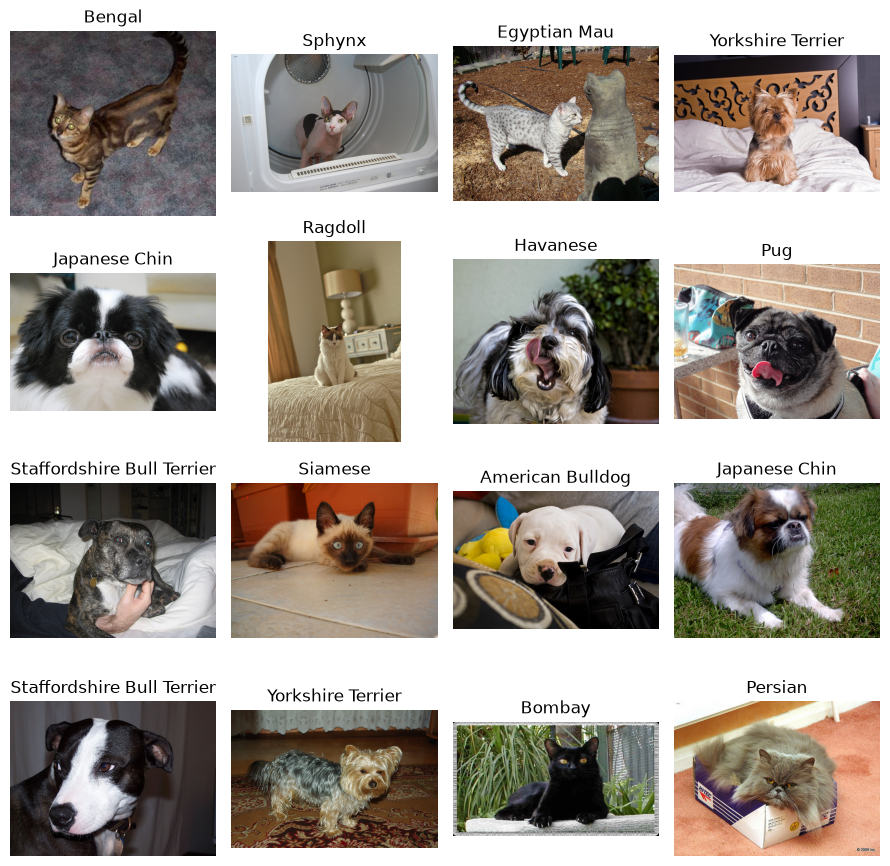

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(raw_data), size=[1]).item()
    img, label = raw_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis(False)
plt.tight_layout()
plt.show()

# Feature Extraction

We are gonna be using a pretrained model, like efficientnet_b0 etc, to train on this data. To select the best model for our need(speed and accuracy), we will try and compare different models. Let's write a few functions to create different models. We are gonna do comparison between three models(efficientnet_b0, resnet50, and mobilenetv3_large).

Since we are gonna be using pretrained models, we will have to modify them for our use(change the outputs to 37).

In [14]:
effnetb0_weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
effnetb0 = torchvision.models.efficientnet_b0(weights=effnetb0_weights)
effnetb0.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

We will have to modify the out_features for our use case, and we will also have to freeze the base layers....to keep the model's already learnt weights.

In [15]:
def create_effnetb0(num_classes: int = 37):
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    transform = weights.transforms()
    model = torchvision.models.efficientnet_b0(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=1280, out_features=num_classes, bias=True)
    )

    return model, transform

In [16]:
effnetb0, effnetb0_transforms = create_effnetb0()

torchinfo.summary(model=effnetb0,
                  input_size=[32, 3, 224, 224],
                  col_names=['input_size', 'output_size', 'trainable'],
                  row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape               Output Shape              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]         [32, 37]                  Partial
├─Sequential (features)                                      [32, 3, 224, 224]         [32, 1280, 7, 7]          False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]         [32, 32, 112, 112]        False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]         [32, 32, 112, 112]        False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]        [32, 32, 112, 112]        False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]        [32, 32, 112, 112]        --
│    └─Sequential (1)                                        [32, 32, 112, 112]        [32, 16, 112, 112]        False
│    │    └─MBConv (0)                       

Everything seems fine, our model is outputing 37 classes and our base layers are freeze.

Let's create resnet50 now.

In [17]:
resnet50_weights = torchvision.models.ResNet50_Weights.DEFAULT
resnet50 = torchvision.models.resnet50(weights=resnet50_weights)
resnet50.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [18]:
def create_resnet50(num_classes: int=37):
    weights = torchvision.models.ResNet50_Weights.DEFAULT
    transform = weights.transforms()
    model = torchvision.models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(in_features=2048, out_features=num_classes, bias=True)

    return model, transform

In [19]:
resnet50, resnet50_transforms = create_resnet50()

torchinfo.summary(model=resnet50,
                  input_size=[32, 3, 224, 224],
                  col_names=['input_size', 'output_size', 'trainable'],
                  row_settings=['var_names'])

Layer (type (var_name))                  Input Shape               Output Shape              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]         [32, 37]                  Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]         [32, 64, 112, 112]        False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]        [32, 64, 112, 112]        False
├─ReLU (relu)                            [32, 64, 112, 112]        [32, 64, 112, 112]        --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]        [32, 64, 56, 56]          --
├─Sequential (layer1)                    [32, 64, 56, 56]          [32, 256, 56, 56]         False
│    └─Bottleneck (0)                    [32, 64, 56, 56]          [32, 256, 56, 56]         False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]          [32, 64, 56, 56]          False
│    │    └─BatchNorm2d (bn1)            [32, 64, 56, 56]          [32, 64, 56, 56]          False
│    │    

And finally, the last one: mobilenet_v3_large.

In [20]:
mobilenetv3l_weights = torchvision.models.MobileNet_V3_Large_Weights.DEFAULT
mobilenetv3l = torchvision.models.mobilenet_v3_large(weights=mobilenetv3l_weights)
mobilenetv3l.classifier

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)

In [21]:
def create_mobilenetv3l(num_classes: int=37):
    weights = torchvision.models.MobileNet_V3_Large_Weights.DEFAULT
    transform = weights.transforms()
    model = torchvision.models.mobilenet_v3_large(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Linear(in_features=960, out_features=1280, bias=True),
        nn.Hardswish(),
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=1280, out_features=num_classes, bias=True)
    )

    return model, transform

In [22]:
mobilenetv3l, mobilenetv3l_transforms = create_mobilenetv3l()

torchinfo.summary(model=mobilenetv3l,
                  input_size=[32, 3, 224, 224],
                  col_names=['input_size', 'output_size', 'trainable'],
                  row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape               Output Shape              Trainable
MobileNetV3 (MobileNetV3)                                    [32, 3, 224, 224]         [32, 37]                  Partial
├─Sequential (features)                                      [32, 3, 224, 224]         [32, 960, 7, 7]           False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]         [32, 16, 112, 112]        False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]         [32, 16, 112, 112]        False
│    │    └─BatchNorm2d (1)                                  [32, 16, 112, 112]        [32, 16, 112, 112]        False
│    │    └─Hardswish (2)                                    [32, 16, 112, 112]        [32, 16, 112, 112]        --
│    └─InvertedResidual (1)                                  [32, 16, 112, 112]        [32, 16, 112, 112]        False
│    │    └─Sequential (block)               

Done.

effnetb0 has the lowest no. of parameters, followed by mobilenetv3l, and resnet50.

Let's create dataloaders for each model. To make it easy, I am gonna create another function.

In [23]:
from going_modular import data_setup
def make_loaders(transform, batch_size=32):
    train_data = torchvision.datasets.OxfordIIITPet(root='data', split='trainval',
                                                    transform=transform, download=True)

    test_data = torchvision.datasets.OxfordIIITPet(root='data', split='test',
                                                    transform=transform, download=True)

    return data_setup.create_dataloaders(train_data, test_data, batch_size)

In [24]:
effnetb0_train_dataloader, effnetb0_test_dataloader = make_loaders(effnetb0_transforms)
resnet50_train_dataloader, resnet50_test_dataloader = make_loaders(resnet50_transforms)
mobilenetv3l_train_dataloader, mobilenetv3l_test_dataloader = make_loaders(mobilenetv3l_transforms)

Done. Now the optimizer and the loss_function, and then model training and comparison.

In [15]:
loss_fn = nn.CrossEntropyLoss()

Since optimizer will also vary for each model, we will write the variables' names with models' names.

In [25]:
effnetb0_optimizer = optim.Adam(effnetb0.parameters(), lr=0.001)
resnet50_optimizer = optim.Adam(resnet50.parameters(), lr=0.001)
mobilenetv3l_optimizer = optim.Adam(mobilenetv3l.parameters(), lr=0.001)

Time to train the models.

In [ ]:
from going_modular import utils, engine
torch.manual_seed(42)
writer = utils.create_writer(experiment_name='cats_vs_dogs_but_37_ways',
                             model_name='effnetb0')

effnetb0_results = engine.train(model=effnetb0,
                                train_dataloader=effnetb0_train_dataloader,
                                test_dataloader=effnetb0_test_dataloader,
                                optimizer=effnetb0_optimizer,
                                loss_fn=loss_fn,
                                epochs=5,
                                device=device,
                                writer=writer)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 || Train Loss: 2.04 || Train Accuracy: 61.79 || Test Loss: 1.13 || Test Accuracy: 79.64
Epoch: 2 || Train Loss: 0.85 || Train Accuracy: 84.73 || Test Loss: 0.73 || Test Accuracy: 83.45
Epoch: 3 || Train Loss: 0.60 || Train Accuracy: 88.80 || Test Loss: 0.63 || Test Accuracy: 84.16
Epoch: 4 || Train Loss: 0.47 || Train Accuracy: 90.57 || Test Loss: 0.58 || Test Accuracy: 84.54
Epoch: 5 || Train Loss: 0.41 || Train Accuracy: 90.92 || Test Loss: 0.54 || Test Accuracy: 85.05


In [ ]:
torch.manual_seed(42)
writer = utils.create_writer(experiment_name='cats_vs_dogs_but_37_ways',
                             model_name='resnet50')

resnet50_results = engine.train(model=resnet50,
                                train_dataloader=resnet50_train_dataloader,
                                test_dataloader=resnet50_test_dataloader,
                                optimizer=resnet50_optimizer,
                                loss_fn=loss_fn,
                                epochs=5,
                                device=device,
                                writer=writer)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 || Train Loss: 1.86 || Train Accuracy: 68.10 || Test Loss: 1.04 || Test Accuracy: 84.81
Epoch: 2 || Train Loss: 0.57 || Train Accuracy: 93.02 || Test Loss: 0.61 || Test Accuracy: 88.82
Epoch: 3 || Train Loss: 0.34 || Train Accuracy: 95.00 || Test Loss: 0.49 || Test Accuracy: 89.36
Epoch: 4 || Train Loss: 0.23 || Train Accuracy: 96.44 || Test Loss: 0.42 || Test Accuracy: 89.93
Epoch: 5 || Train Loss: 0.19 || Train Accuracy: 97.31 || Test Loss: 0.38 || Test Accuracy: 90.45


In [ ]:
torch.manual_seed(42)
writer = utils.create_writer(experiment_name='cats_vs_dogs_but_37_ways',
                             model_name='mobilenetv3l')

mobilenetv3l_results = engine.train(model=mobilenetv3l,
                                train_dataloader=mobilenetv3l_train_dataloader,
                                test_dataloader=mobilenetv3l_test_dataloader,
                                optimizer=mobilenetv3l_optimizer,
                                loss_fn=loss_fn,
                                epochs=5,
                                device=device,
                                writer=writer)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 || Train Loss: 1.21 || Train Accuracy: 66.33 || Test Loss: 0.48 || Test Accuracy: 84.17
Epoch: 2 || Train Loss: 0.41 || Train Accuracy: 86.58 || Test Loss: 0.52 || Test Accuracy: 83.12
Epoch: 3 || Train Loss: 0.28 || Train Accuracy: 91.25 || Test Loss: 0.58 || Test Accuracy: 82.23
Epoch: 4 || Train Loss: 0.21 || Train Accuracy: 93.07 || Test Loss: 0.53 || Test Accuracy: 84.21
Epoch: 5 || Train Loss: 0.16 || Train Accuracy: 94.32 || Test Loss: 0.62 || Test Accuracy: 82.36


In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

resnet50 is performing the best among the three models, followed by effnetb0. Their loss is still decreasing at 5 epochs, so let's retrain the both models, with 10 epochs.

The mobilenetv3l is performing the worst among the three models, with the highest loss. So, we'll skip it and focus on the other two.

In [18]:
from going_modular import utils, engine
torch.manual_seed(42)
writer = utils.create_writer(experiment_name='cats_vs_dogs_but_37_ways',
                             model_name='effnetb0_10_epochs')

effnetb0_v2, effnetb0_transforms = create_effnetb0()
effnetb0_v2 = effnetb0_v2.to(device)
effnetb0_v2_optimizer = optim.Adam(effnetb0_v2.parameters(), lr=0.001)

effnetb0_results_10_epochs = engine.train(model=effnetb0_v2,
                                train_dataloader=effnetb0_train_dataloader,
                                test_dataloader=effnetb0_test_dataloader,
                                optimizer=effnetb0_v2_optimizer,
                                loss_fn=loss_fn,
                                epochs=10,
                                device=device,
                                writer=writer)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 || Train Loss: 2.04 || Train Accuracy: 62.31 || Test Loss: 1.10 || Test Accuracy: 80.75
Epoch: 2 || Train Loss: 0.85 || Train Accuracy: 84.89 || Test Loss: 0.77 || Test Accuracy: 82.59
Epoch: 3 || Train Loss: 0.60 || Train Accuracy: 88.10 || Test Loss: 0.65 || Test Accuracy: 83.63
Epoch: 4 || Train Loss: 0.48 || Train Accuracy: 90.14 || Test Loss: 0.59 || Test Accuracy: 84.25
Epoch: 5 || Train Loss: 0.40 || Train Accuracy: 91.58 || Test Loss: 0.55 || Test Accuracy: 85.05
Epoch: 6 || Train Loss: 0.35 || Train Accuracy: 92.93 || Test Loss: 0.52 || Test Accuracy: 85.08
Epoch: 7 || Train Loss: 0.31 || Train Accuracy: 93.37 || Test Loss: 0.52 || Test Accuracy: 84.74
Epoch: 8 || Train Loss: 0.26 || Train Accuracy: 94.67 || Test Loss: 0.49 || Test Accuracy: 85.82
Epoch: 9 || Train Loss: 0.24 || Train Accuracy: 95.24 || Test Loss: 0.49 || Test Accuracy: 85.15
Epoch: 10 || Train Loss: 0.23 || Train Accuracy: 95.68 || Test Loss: 0.48 || Test Accuracy: 85.33


In [ ]:
torch.manual_seed(42)
writer = utils.create_writer(experiment_name='cats_vs_dogs_but_37_ways',
                             model_name='resnet50_10_epochs')

resnet50_v2, resnet50_transforms = create_resnet50()
resnet50_v2 = resnet50_v2.to(device)
resnet50_v2_optimizer = optim.Adam(resnet50_v2.parameters(), lr=0.001)

resnet50_results_10_epochs = engine.train(model=resnet50_v2,
                                train_dataloader=resnet50_train_dataloader,
                                test_dataloader=resnet50_test_dataloader,
                                optimizer=resnet50_v2_optimizer,
                                loss_fn=loss_fn,
                                epochs=10,
                                device=device,
                                writer=writer)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 || Train Loss: 1.85 || Train Accuracy: 68.72 || Test Loss: 1.02 || Test Accuracy: 85.68
Epoch: 2 || Train Loss: 0.56 || Train Accuracy: 92.55 || Test Loss: 0.60 || Test Accuracy: 88.90
Epoch: 3 || Train Loss: 0.34 || Train Accuracy: 95.19 || Test Loss: 0.47 || Test Accuracy: 90.24
Epoch: 4 || Train Loss: 0.24 || Train Accuracy: 96.60 || Test Loss: 0.40 || Test Accuracy: 90.61
Epoch: 5 || Train Loss: 0.18 || Train Accuracy: 97.69 || Test Loss: 0.39 || Test Accuracy: 90.09
Epoch: 6 || Train Loss: 0.15 || Train Accuracy: 98.21 || Test Loss: 0.34 || Test Accuracy: 91.03
Epoch: 7 || Train Loss: 0.12 || Train Accuracy: 98.45 || Test Loss: 0.34 || Test Accuracy: 90.65
Epoch: 8 || Train Loss: 0.10 || Train Accuracy: 98.97 || Test Loss: 0.32 || Test Accuracy: 90.79
Epoch: 9 || Train Loss: 0.09 || Train Accuracy: 99.18 || Test Loss: 0.31 || Test Accuracy: 91.26
Epoch: 10 || Train Loss: 0.07 || Train Accuracy: 99.48 || Test Loss: 0.30 || Test Accuracy: 91.22


In [26]:
%reload_ext tensorboard
%tensorboard --logdir runs

Reusing TensorBoard on port 6006 (pid 43730), started 0:44:45 ago. (Use '!kill 43730' to kill it.)

Resnet50 is the best performing model with 91% test accuracy at 10 epochs, and the lowest test loss(0.3025) as compared to effnetb0. We'll fine tune it in the next notebook. 

However, let's see how much time does each model takes on cpu to classify an image.

In [28]:
import time, torch, torchvision

def cpu_latency(model, n=50, size=224):
    model.eval()
    x = torch.randn(1, 3, size, size)  
    with torch.inference_mode():
        model(x)  #warmup
        start = time.time()

        for _ in range(n):
            model(x)
            
        end = time.time()
    return (end - start) / n * 1000   # ms per image

print("resnet50", cpu_latency(torchvision.models.resnet50()))
print("effnetb0", cpu_latency(torchvision.models.efficientnet_b0()))
print("mobilenetv3l", cpu_latency(torchvision.models.mobilenet_v3_large()))

resnet50 144.66757774353027
effnetb0 49.50636863708496
mobilenetv3l 29.995946884155273


resnet50 is taking about 3x the time as compared to effnetb0. Let's suppose if the mobile, on which this model will run, is 4 times slower than this laptop...still it would be done within a sec which is not much of a wait for a normal human, or is it? We'll see.

## **P.S: I ran the model training sessions on google colab, and I forgot to save the resnet50 model after training it for 10 epochs...now I have to retrain it in the next notebook...shit :)**